In [ ]:
'''
This is Auto ML project , in which user can upload their dataset and then all ML spteps will be done automatically.
For this User just need to upload the dataset and select the target variable.

Here We code and test all the functions that are used  for our project.
This file is part of the project:
1. Load the dataset 
2. Analyze the dataset find the traget variable
3. Preprocess the data
4. Train the different models for the data
5. Evaluate the models and select the best one
6. Preform hyperparameter tuning on the best model
7. Save the model for future use
8. Create a web interface for the user to interact with the model
'''

Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings(action="ignore")

class Preprocess:
    def __init__(self, df, target):
        self.df = df
        self.target = target
        if self.df[target].dtype == 'object':
            self.type = 'categorical'
        else:
            self.type = 'numerical'
    def handle_duplicate_rows(self):
        # Check for duplicate rows
        if self.df.duplicated().any():
            # Remove duplicate rows
            self.df = self.df.drop_duplicates()
        
        return self.df
    def handle_missing_values(self):
        for column in self.df.columns:
            if self.df[column].isnull().any():
                if self.df[column].dtype == 'object':
                    # Fill categorical missing values with the mode
                    self.df[column].fillna(self.df[column].mode()[0], inplace=True)
                else:
                    # Fill numerical missing values with the mean
                    self.df[column].fillna(self.df[column].median(), inplace=True)

        return self.df
    def handle_outliers(self):
        for column in self.df.select_dtypes(include=['float64', 'int64']).columns:
            # Calculate the IQR
            Q1 = self.df[column].quantile(0.25)
            Q3 = self.df[column].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define bounds for outliers
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Replace outliers with the median
            self.df[column] = self.df[column].apply(lambda x: x if (x >= lower_bound and x <= upper_bound) else self.df[column].median())
        
        return self.df
    # def handel_categorical_data(self):
    #     # Convert categorical variables to numerical
    #     self.df = pd.get_dummies(self.df, drop_first=True)
        
    #     # Separate features and target variable
    #     X = self.df.drop(columns=[self.target])
    #     y = self.df[self.target]
        
    #     return X, y
    def handle_categorical_data(self):
        # Convert categorical variables to numerical
        for column in self.df.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            self.df[column] = le.fit_transform(self.df[column])
        
        # Separate features and target variable
        X = self.df.drop(columns=[self.target])
        y = self.df[self.target]
        
        return X, y, le
    
    def scale_data(self, X):
        # Scale the data using StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        self.X = pd.DataFrame(X_scaled, columns=X.columns)
        
        return X, scaler
    def preprocess(self):
        # Handle duplicate rows
        self.df = self.handle_duplicate_rows()
        # Handle missing values
        self.df = self.handle_missing_values()
        
        # Handle outliers
        self.df = self.handle_outliers()
        
        # Handle categorical data
        X, y, le = self.handle_categorical_data()
        
        # Scale the data
        X_scaled, scaler = self.scale_data(X)
        
        return X_scaled, y, le, scaler ,self.type

In [2]:
df=pd.read_csv('/Users/abhishekkanade/Documents/notebook/DA/diamonds dataset.csv')
preprocessor = Preprocess(df, target='Type')



In [3]:
X_scaled, y, le, scaler ,type= preprocessor.preprocess()

In [4]:
X_scaled.head(), y.head(), le.classes_, scaler.mean_

(   Shape  Cut  Color  Clarity  Carat Weight  Length/Width Ratio  Depth %  \
 0      1    2      2        5          1.03                1.02     65.8   
 1      6    2      1        2          1.20                1.65     62.5   
 2      5    2      1        2          1.19                1.41     63.1   
 3      3    2      0        1          1.00                1.18     61.7   
 4      8    2      4        2          1.01                1.35     69.4   
 
    Table %  Polish  Symmetry  Girdle  Culet  Length  Width  Height   Price  \
 0     59.0       0         2       7      1    7.09   6.95    4.57  2640.0   
 1     58.0       2         2       7      1    9.64   5.86    3.66  1070.0   
 2     63.0       2         2       7      1    8.44   6.00    3.79  1070.0   
 3     58.0       0         0      13      1    5.85   6.89    4.25  7110.0   
 4     66.0       0         2      14      1    6.80   5.05    3.50  3050.0   
 
    Fluorescence  
 0             0  
 1             0  
 2 

In [5]:
le.classes_

array(['Faint', 'Medium', 'Strong'], dtype=object)

In [4]:
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.svm import SVC,SVR

In [18]:
# Collection of models
'''
We Have add functionality to identify the type of target variable and then train the models accordingly.
'''


Regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Support Vector Regressor': SVR()
}
Classification_models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Random Forest Classifier': RandomForestClassifier(),
    'Support Vector Classifier': SVC()
}
def train_models(X, y,type):
    results = {}
    models=[]
    if type == 'categorical':
        # Classification task

        for name, model in Classification_models.items():
            model.fit(X, y)
            score = model.score(X, y)
            results[name] = score
            models.append(model)
        return results , models
    else:
        # Regression task
       
        for name, model in Regression_models.items():
            model.fit(X, y)
            score = model.score(X, y)
            results[name] = score
            models.append(model)
        return results, models
   

In [19]:
trained_models,models = train_models(X_scaled, y,type )


In [20]:
def best_model(results,models):
    # Find the best model based on the highest score
    best_model_name = max(results, key=results.get)
    best_model_score = results[best_model_name]
    best_model = models[list(results.keys()).index(best_model_name)]
    
    return best_model_name, best_model_score , best_model

In [21]:
best_model_name, best_model_score, best_model = best_model(trained_models,models)
print(f"Best Model: {best_model_name} with score: {best_model_score}")

Best Model: Decision Tree Classifier with score: 1.0


In [23]:
def hyperparameter_tuning(model, X, y):
    from sklearn.model_selection import GridSearchCV
    
    # Define hyperparameters to tune
    if isinstance(model, RandomForestRegressor) or isinstance(model, RandomForestClassifier):
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    elif isinstance(model, DecisionTreeRegressor) or isinstance(model, DecisionTreeClassifier):
        param_grid = {
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    else:
        param_grid = {}
    
    grid_search = GridSearchCV(model, param_grid, cv=5)
    grid_search.fit(X, y)
    
    return grid_search.best_estimator_

In [24]:
model= hyperparameter_tuning(best_model, X_scaled, y)

In [32]:
print(model.predict(X_scaled[0:5]))
print(y[0:5])

[1 1 1 0 0]
0    1
1    1
2    1
3    0
4    0
Name: Type, dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.svm import SVC,SVR
class ModelsTrainer:
    
    def __init__(self,X_scaled, y, le, scaler ,type):
        self.X_scaled = X_scaled
        self.y = y
        self.le = le
        self.scaler = scaler
        self.type = type
        
    Regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Support Vector Regressor': SVR()
    }
    Classification_models = {
        'Logistic Regression': LogisticRegression(),
        'Decision Tree Classifier': DecisionTreeClassifier(),
        'Random Forest Classifier': RandomForestClassifier(),
        'Support Vector Classifier': SVC()
    }
    def train_models(self):
        results = {}
        models = []
        if self.type == 'categorical':
            # Classification task
            for name, model in self.Classification_models.items():
                model.fit(self.X_scaled, self.y)
                score = model.score(self.X_scaled, self.y)
                results[name] = score
                models.append(model)
            return results, models
        else:
            # Regression task
            for name, model in self.Regression_models.items():
                model.fit(self.X_scaled, self.y)
                score = model.score(self.X_scaled, self.y)
                results[name] = score
                models.append(model)
            return results, models
        
    def best_model(self,results,models):
        # Find the best model based on the highest score
        best_model_name = max(results, key=results.get)
        best_model_score = results[best_model_name]
        best_model = models[list(results.keys()).index(best_model_name)]
        
        return best_model_name, best_model_score , best_model
    def hyperparameter_tuning(self, model):
        from sklearn.model_selection import GridSearchCV
        
        # Define hyperparameters to tune
        if isinstance(model, RandomForestRegressor) or isinstance(model, RandomForestClassifier):
            param_grid = {
                'n_estimators': [50, 100, 200],
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5, 10]
            }
        elif isinstance(model, DecisionTreeRegressor) or isinstance(model, DecisionTreeClassifier):
            param_grid = {
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5, 10]
            }
        else:
            param_grid = {}
        
        grid_search = GridSearchCV(model, param_grid, cv=5)
        grid_search.fit(self.X_scaled, self.y)
        
        return grid_search.best_estimator_
    
    def train(self):
        trained_models, models = self.train_models()
        best_model_name, best_model_score, best_model = self.best_model(trained_models, models)
        print(f"Best Model: {best_model_name} with score: {best_model_score}")
        tuned_model = self.hyperparameter_tuning(best_model)
        
        return tuned_model

In [1]:
from Preprocess import Preprocess

In [3]:
import pandas as pd

In [61]:
df=pd.read_csv('/Users/abhishekkanade/Documents/notebook/DA/diamonds dataset.csv')

In [84]:
pre= Preprocess(df, target='Shape')

In [85]:
X_scaled,y,le,scaler,type= pre.preprocess()

In [73]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [86]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,random_state=42)

In [68]:
model=SVC()

In [76]:
pred=model.predict(x_test)

In [77]:
from sklearn.metrics import classification_report
print(classification_report(y_true=y_test,y_pred=pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1499
           1       0.00      0.00      0.00        76
           2       0.00      0.00      0.00        46

    accuracy                           0.92      1621
   macro avg       0.31      0.33      0.32      1621
weighted avg       0.86      0.92      0.89      1621



In [75]:
model.fit(x_train,y_train)

SVC()

In [7]:
X_scaled

,Shape,Cut,Color,Clarity,Carat Weight,Length/Width Ratio,Depth %,Table %,Polish,Symmetry,Girdle,Culet,Length,Width,Height,Price,Fluorescence
0,-1.903174,0.152793,0.265078,1.883202,-0.182620,-0.953751,0.333135,-0.592977,-0.294601,1.600608,-0.633124,-0.060796,-0.321532,1.189991,1.764889,-0.260506,-0.279248
1,0.169261,0.152793,-0.434529,-0.723628,2.648104,1.001958,-0.361355,-0.809718,3.457074,1.600608,-0.633124,-0.060796,1.317836,-0.089089,-0.300595,-1.155956,-0.279248
2,-0.245226,0.152793,-0.434529,-0.723628,2.481591,0.256926,-0.235084,0.273985,3.457074,1.600608,-0.633124,-0.060796,0.546369,0.075196,-0.005526,-1.155956,-0.279248
3,-1.074200,0.152793,-1.134136,-1.592571,-0.682160,-0.457063,-0.529716,-0.809718,-0.294601,-0.639759,0.547008,-0.060796,-1.118715,1.119583,1.038565,2.288962,-0.279248
4,0.998234,0.152793,1.664292,-0.723628,-0.515646,0.070668,1.090759,0.924207,-0.294601,1.600608,0.743697,-0.060796,-0.507970,-1.039598,-0.663757,-0.026662,-0.279248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6477,0.169261,0.152793,0.265078,0.145315,-0.349133,0.660485,-0.277174,0.273985,-0.294601,1.600608,1.137074,-0.060796,0.649231,-0.405926,-0.641059,0.378287,2.163515
6478,-1.074200,0.152793,-0.434529,1.883202,-0.682160,-0.519149,-1.245251,-0.592977,-0.294601,-0.639759,0.547008,-0.060796,-0.990137,1.236930,0.630008,0.920120,4.606278
6479,0.583747,0.152793,0.964685,1.014259,-0.182620,-0.984794,1.764204,2.007911,-0.294601,-0.639759,-0.829812,-0.060796,-1.285866,-0.499803,0.471124,0.098815,-0.279248
6480,0.998234,0.152793,-0.434529,-0.723628,0.316920,0.319012,0.754037,0.057245,-0.294601,-0.639759,0.350319,-0.060796,-0.225099,-1.039598,-0.845337,-1.167363,-0.279248


In [21]:
new=df.head()

In [22]:
new

,Shape,Cut,Color,Clarity,Carat Weight,Length/Width Ratio,Depth %,Table %,Polish,Symmetry,Girdle,Culet,Length,Width,Height,Price,Type,Fluorescence
0,Cushion Modified,Ideal,F,VVS2,1.84,1.02,65.8,59.0,Excellent,Very Good,Medium to Thick,NaN,7.09,6.95,4.57,2640,GIA Lab-Grown,NaN
1,Pear,NaN,E,VS1,1.20,1.65,62.5,58.0,Very Good,Very Good,Medium to Thick,NaN,9.64,5.86,3.66,1070,GIA Lab-Grown,NaN
2,Oval,NaN,E,VS1,1.19,1.41,63.1,63.0,Very Good,Very Good,Medium to Thick,NaN,8.44,6.00,3.79,1070,GIA Lab-Grown,NaN
3,Heart,NaN,D,IF,1.00,1.18,61.7,58.0,Excellent,Excellent,Slightly Thick to Very Thick,NaN,5.85,6.89,4.25,7110,GIA,Faint
4,Radiant,NaN,H,VS1,1.01,1.35,69.4,66.0,Excellent,Very Good,Thick,NaN,6.80,5.05,3.50,3050,GIA,NaN


In [83]:
from ModelsTrainer import ModelsTrainer
from Preprocess import Preprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings(action="ignore")

df=pd.read_csv('/Users/abhishekkanade/Documents/notebook/DA/diamonds dataset.csv')
preprocessor = Preprocess(df, target='Shape')
X_scaled, y, le, scaler ,type= preprocessor.preprocess()
trainer = ModelsTrainer(X_scaled, y, le, scaler, type)
res,tuned_model = trainer.train()


Best Model: Random Forest Classifier with score: 0.9760986892829607
Hyperparameters Tuning started ...
Tuned Model: RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=42)


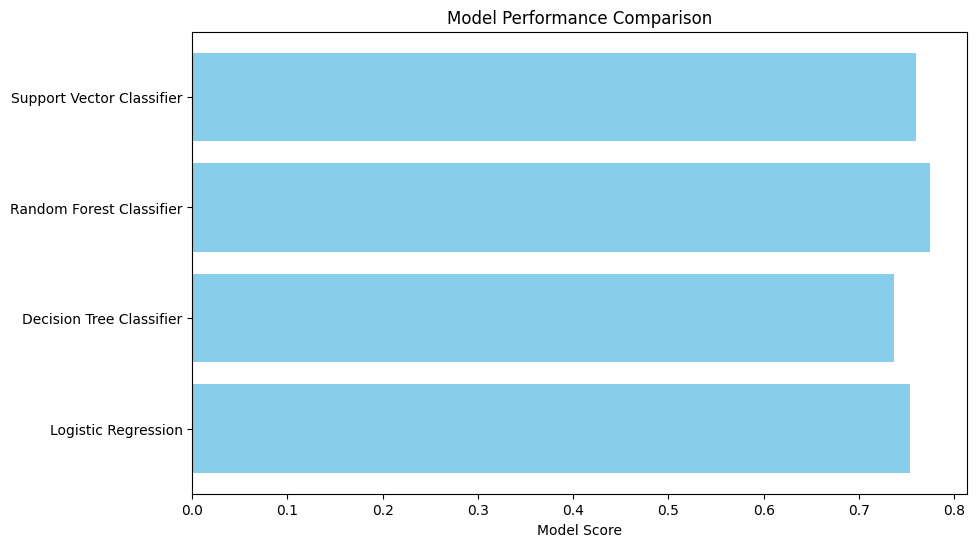

In [82]:
plt.figure(figsize=(10, 6))
plt.barh(list(res.keys()), list(res.values()), color='skyblue')
plt.xlabel('Model Score')
plt.title('Model Performance Comparison')
plt.show()

In [89]:
n,m=le['Shape'].inverse_transform(tuned_model.predict(x_test)),le['Shape'].inverse_transform(y_test)

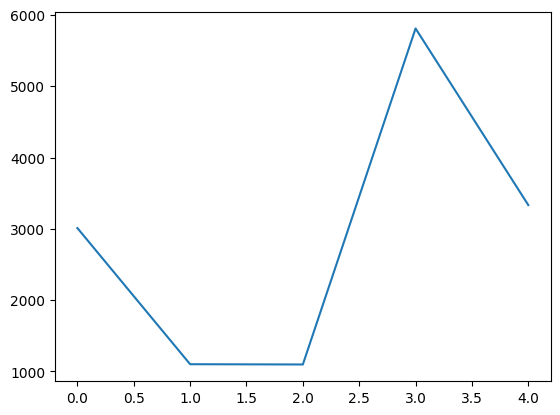

In [4]:
plt.plot(X)

0.0